In [1]:
import pandas as pd

In [2]:
tokenised_prompt = pd.read_pickle("tokenised_prompt.pkl")

In [3]:
tokenised_prompt.head()

,attention_mask,input_ids
0,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 235276, 141, 204, 235322, 235371, 1645, 23..."
1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 235276, 141, 204, 235322, 235371, 1645, 23..."
2,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 235276, 141, 204, 235322, 235371, 1645, 23..."
3,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 235276, 141, 204, 235322, 235371, 1645, 23..."
4,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 235276, 141, 204, 235322, 235371, 1645, 23..."


In [4]:
# !pip install torch transformers datasets accelerate peft bitsandbytes

In [5]:
model_id = "google/gemma-2b"

In [6]:
from transformers import AutoModelForCausalLM

In [7]:
from huggingface_hub import notebook_login
notebook_login()

In [8]:
model = AutoModelForCausalLM.from_pretrained(model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/627 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/13.5k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/67.1M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

In [9]:
from transformers import AutoTokenizer

In [10]:
model_id = "google/gemma-2b"
tokeniser = AutoTokenizer.from_pretrained(model_id)
print("model loaded succesfully")

tokenizer_config.json:   0%|          | 0.00/33.6k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

model loaded succesfully


In [11]:
prompt = "If 4x + i(3x – y) = 3 + i (– 6), where x and y are real numbers, then find the values of x and y."
example_prompt = tokeniser(prompt)

In [12]:
example_prompt

{'input_ids': [2, 2495, 235248, 235310, 235297, 963, 496, 235278, 235304, 235297, 1157, 597, 235275, 589, 235248, 235304, 963, 496, 591, 235389, 235248, 235318, 823, 1570, 1141, 578, 597, 708, 1879, 5968, 235269, 1492, 1717, 573, 4035, 576, 1141, 578, 597, 235265], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [13]:
input_id = example_prompt["input_ids"]

In [14]:
import torch

In [15]:
input_id = torch.tensor(input_id)
d = len(input_id)

In [16]:
input_id = input_id.reshape([1 , d])

In [17]:
input_id

tensor([[     2,   2495, 235248, 235310, 235297,    963,    496, 235278, 235304,
         235297,   1157,    597, 235275,    589, 235248, 235304,    963,    496,
            591, 235389, 235248, 235318,    823,   1570,   1141,    578,    597,
            708,   1879,   5968, 235269,   1492,   1717,    573,   4035,    576,
           1141,    578,    597, 235265]])

In [18]:
output_id = model.generate(input_id)

In [19]:
output_id

tensor([[     2,   2495, 235248, 235310, 235297,    963,    496, 235278, 235304,
         235297,   1157,    597, 235275,    589, 235248, 235304,    963,    496,
            591, 235389, 235248, 235318,    823,   1570,   1141,    578,    597,
            708,   1879,   5968, 235269,   1492,   1717,    573,   4035,    576,
           1141,    578,    597, 235265,    109,   1261, 235292,    109,   5856,
         235248, 235274, 235283, 235284,    108,   5546, 235269,    783,   1476,
            577,  48180,    573,   2731, 235290,   3345]])

In [21]:
tokeniser.decode(output_id[0])

'<bos>If 4x + i(3x – y) = 3 + i (– 6), where x and y are real numbers, then find the values of x and y.\n\nAnswer:\n\nStep 1/2\nFirst, we need to simplify the left-hand'

In [22]:
tokenised_data = pd.read_pickle("tokenised_prompt.pkl")

In [23]:
# creating a dataloader
import torch
from torch.utils.data import DataLoader
from datasets import Dataset


In [24]:
tokenised_data.head()

,attention_mask,input_ids
0,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 235276, 141, 204, 235322, 235371, 1645, 23..."
1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 235276, 141, 204, 235322, 235371, 1645, 23..."
2,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 235276, 141, 204, 235322, 235371, 1645, 23..."
3,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 235276, 141, 204, 235322, 235371, 1645, 23..."
4,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 235276, 141, 204, 235322, 235371, 1645, 23..."


In [25]:
tokenised_df = Dataset.from_pandas(tokenised_data)

In [26]:

tokenised_df.set_format(
    type = "torch",
    columns = ["attention_mask", "input_ids"]
)

In [27]:

from transformers import DataCollatorWithPadding

In [28]:
data_collator = DataCollatorWithPadding(tokeniser)

In [29]:
dataloader = DataLoader(
    tokenised_df,
    batch_size = 4,
    shuffle = True,
    collate_fn = data_collator
)

In [30]:
# what do we need for lora
# rank = 16
# lora alpha = 32
# task_type = CASUAL_LM
# target_module = q_proj, k_proj, v_proj



In [31]:
from peft import LoraConfig, LoraModel # what does "LoraModel" do?

In [32]:
lora_config = LoraConfig(
    r = 16, lora_alpha = 32,
    target_modules = ["q_proj", "o_proj", "k_proj", "v_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout = 0.1,
    task_type="CAUSAL_LM"
)

In [33]:
lora_model = LoraModel(
    model, lora_config, "default"
)

In [34]:
lora_model = lora_model.to("cuda")

In [35]:
params = []
for param in lora_model.parameters():
  if param.requires_grad == True:
    params.append(param)


In [36]:
loss_fn = torch.nn.CrossEntropyLoss()
optimiser = torch.optim.AdamW(params = params, lr=0.001)


model.train()

loop for epochs

loop for every datapoints

move batch to cuda

perform forward loss

get loss

perform backward pass


update weights

zero the optimiser gradient




In [37]:
device = "cuda"
from tqdm import tqdm


In [38]:
epochs = 3
training_loss = []
lora_model = lora_model.to(device)

In [39]:
lenght_of_attention_mask = []
lenght_of_inputIds = []
for n , batch in enumerate(dataloader):
  for name , related_tensor in batch.items():
    if name == "attention_mask":
      lenght_of_attention_mask.append(len(related_tensor))
    else:
      lenght_of_inputIds.append(len(related_tensor))

In [40]:
print(n)

142


In [41]:
print(lenght_of_inputIds[:10])

[4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


In [42]:
for batch in dataloader:
  batch = {name : related_tensor.to(device) for name , related_tensor in batch.items()}
  outputs = lora_model(**batch)
  print(outputs.loss)
  break

None


In [43]:
lora_model.train()
for i in range(epochs):
  total_loss = 0
  for batch in tqdm(dataloader):
      batch = {name : related_tensor.to(device) for name , related_tensor in batch.items()}
      labels = batch["input_ids"]
      outputs = lora_model(**batch, labels = labels)
      loss = outputs.loss
      loss.backward()
      optimiser.step()
      optimiser.zero_grad()
      total_loss += loss
      training_loss.append(loss)
  avg_loss = total_loss / len(dataloader)
  print(f"avergae loss of {i+1}th epochs is {avg_loss}")

100%|██████████| 143/143 [01:21<00:00,  1.76it/s]


avergae loss of 1th epochs is 3.219322443008423


100%|██████████| 143/143 [01:33<00:00,  1.53it/s]


avergae loss of 2th epochs is 1.3727213144302368


100%|██████████| 143/143 [01:32<00:00,  1.55it/s]

avergae loss of 3th epochs is 1.3330811262130737


In [45]:
training_loss = [float(t.to("cpu").detach()) for t in training_loss]

In [46]:
from  math import log10
log_loss = [log10(x) for x in training_loss]

In [47]:
number_iter = [i+1 for i in range(429)]

In [48]:
import seaborn as sns

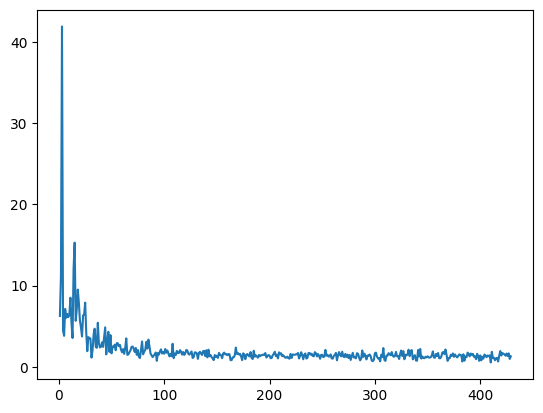

In [51]:
sns.lineplot(y = training_loss, x = number_iter);

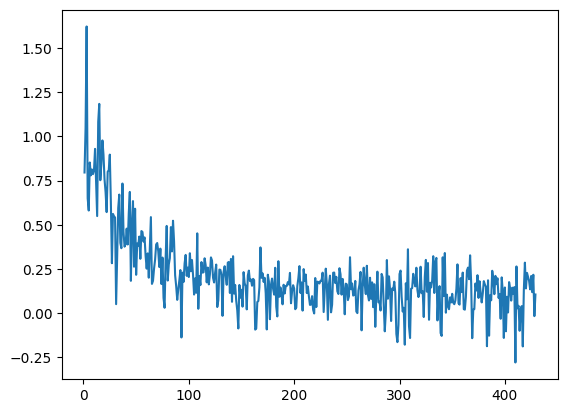

In [52]:
sns.lineplot(y = log_loss, x = number_iter);

In [55]:
lora_model.train(False)

print("model set to non training model")

model set to non training model


In [89]:
output_for_n =  model.generate(input_id.to("cuda"), max_new_tokens = 100)
output_for_p = lora_model.generate(input_id.to("cuda"),  max_new_tokens = 100)

In [90]:
solution_n = tokeniser.decode(output_for_n[0])
solution_p = tokeniser.decode(output_for_p[0])

In [91]:
print(f"answer of non finetuned model to the question [{prompt}] is: ")
print("")
print(f"{solution_n}")

answer of non finetuned model to the question [If 4x + i(3x – y) = 3 + i (– 6), where x and y are real numbers, then find the values of x and y.] is: 

<bos>If 4x + i(3x – y) = 3 + i (– 6), where x and y are real numbers, then find the values of x and y. Show the...
Name: 146, dtype: object<eos>


In [81]:
print(f"answer of finetuned model to the question [{prompt}] is: ")
print("")
print(f"{solution_p}")

answer of finetuned model to the question [If 4x + i(3x – y) = 3 + i (– 6), where x and y are real numbers, then find the values of x and y.] is: 

<bos>If 4x + i(3x – y) = 3 + i (– 6), where x and y are real numbers, then find the values of x and y. Show the...
Name: 146, dtype: object<eos>
